In [62]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [54]:
# Data
x_train = pd.read_csv("../data/x_train_final.csv")
y_train = pd.read_csv("../data/y_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [55]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [56]:
y_train

,Unnamed: 0,p0q0
0,0,-1.0
1,1,-1.0
2,2,-1.0
3,3,1.0
4,4,3.0
...,...,...
667259,667259,1.0
667260,667260,2.0
667261,667261,2.0
667262,667262,1.0


## Feature Engineering

In [ ]:
def engineer_features_train(df: pd.DataFrame , y_train: pd.DataFrame) -> pd.DataFrame:
    
    df = df.copy()
    
    # Transformation basique
    df["p0q0"] = y_train["p0q0"]

    
    # Transformation de la date
    df["date"] = pd.to_datetime(df["date"])
    
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    
    
    # Encodage cyclique
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5) # 5 jour dans la semaine ( y a pas de weekend)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5) # 5 jour dans la semaine ( y a pas de weekend)
    
    # Encodage target encoding : train et gare
    encoded_gare = target_encode_cv(df,"gare","p0q0")
    encoded_train = target_encode_cv(df,"train","p0q0")

    df["encoded_train"] = encoded_train
    df["encoded_gare"] = encoded_gare
    
    # Outliers
    df.loc[df["p0q3"] <= -500, "p0q3"] = np.mean([df["p0q2"] , df["p0q4"]])
    df.loc[df["p0q4"] <= -500, "p0q4"] = np.mean([df["p0q2"] , df["p0q3"]])
    
    # Features agregées
    df["somme_retard_prev_trains"] = np.sum([df["p2q0"] , df["p3q0"] , df["p4q0"]])
    df["somme_retard_prev_gares"] = np.sum([df["p0q2"] , df["p0q3"] , df["p0q4"]])
    
    
    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
    
    # Moyenne de tous les retards par gare
    retard_moyen_par_gare = df.groupby("gare")[cols_retard].mean().mean(axis=1)
    df["retard_moyen_gare"] = df["gare"].map(retard_moyen_par_gare)
    
    # Moyenne des retards par train
    retard_moyen_par_train = df.groupby("train")[cols_retard].mean().mean(axis=1)
    df["retard_moyen_par_train"] = df["train"].map(retard_moyen_par_train)
    
    # Nombre d'arrêt par train
    df["nb_arrets"] = df.groupby(["train", "date"])["arret"].transform("count")

    cols_to_drop = ["Unnamed: 0.1" , "Unnamed: 0" , "year" , "date" , "day_of_week","month" ,"day" , "gare" ,"train"]
    
    df = df.drop(columns=cols_to_drop , axis=1)
    
    return df


def target_encode_cv(df, cat_col, target, n_splits=5):
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    encoded = np.zeros(len(df))
    
    for train_index, val_index in kf.split(df):
        
        train_df = df.iloc[train_index]
        val_df = df.iloc[val_index]
        
        means = train_df.groupby(cat_col)[target].mean()
        
        encoded[val_index] = val_df[cat_col].map(means)
    
    return encoded

In [58]:
x_train_fe = engineer_features_train(x_train,y_train)

In [61]:
x_train_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,p0q0,month_sin,month_cos,day_of_week_sin,day_of_week_cos,encoded_train,encoded_gare,somme_retard_prev_trains,somme_retard_prev_gares,retard_moyen_gare,retard_moyen_par_train,nb_arrets
0,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,-1.0,0.866025,-0.500000,0.000000,1.000000,0.500000,-0.958800,1.0,-6.0,-0.566903,-0.200000,5
1,9,0.0,0.0,0.0,1.0,0.0,1.0,-1.0,0.866025,-0.500000,0.000000,1.000000,-0.333333,0.304619,0.0,2.0,-0.093991,-0.200000,5
2,10,-1.0,0.0,0.0,-1.0,0.0,0.0,-1.0,0.866025,-0.500000,0.000000,1.000000,0.500000,0.171438,-1.0,-1.0,-0.183342,-0.200000,5
3,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,1.0,0.866025,-0.500000,0.000000,1.000000,0.000000,-0.525163,-2.0,0.0,-0.436343,-0.200000,5
4,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,3.0,0.866025,-0.500000,0.000000,1.000000,-0.333333,-0.324226,-3.0,4.0,-0.316142,-0.200000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,1.0,-0.500000,0.866025,-0.951057,0.309017,0.000000,0.416749,-7.0,-3.0,-0.066706,-0.850877,19
667260,23,0.0,0.0,-1.0,1.0,0.0,0.0,2.0,-0.500000,0.866025,-0.951057,0.309017,-0.250000,0.666288,-1.0,1.0,0.336298,-0.850877,19
667261,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,2.0,-0.500000,0.866025,-0.951057,0.309017,-0.461538,0.488306,1.0,-5.0,0.394514,-0.850877,19
667262,26,2.0,2.0,1.0,0.0,0.0,1.0,1.0,-0.500000,0.866025,-0.951057,0.309017,0.000000,0.338214,5.0,1.0,0.395858,-0.850877,19


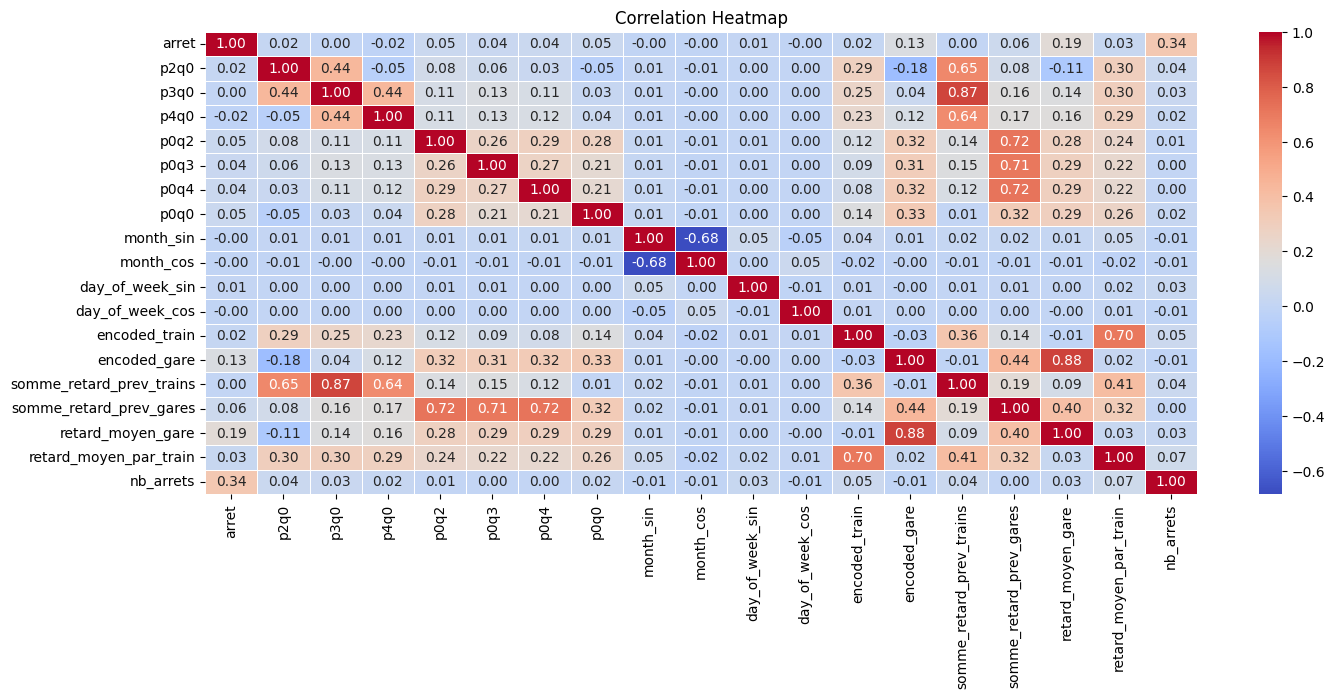

In [60]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## X_test

In [68]:
x_test[x_test["train"] == "VBXNMF"]

,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
